**Importing Necessary Libraries**

In [22]:
import os
import random
import numpy as np
import pandas as pd
import librosa
from scipy import stats
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter


# sklearn
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, precision_score, recall_score, classification_report, confusion_matrix

# tree learners
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

**Setting a Fixed Random Seed for Reproducibility**

In [2]:
# reproducibility
RND_SEED = 42
np.random.seed(RND_SEED)
random.seed(RND_SEED)

**Paths Defined**

In [3]:
TRAIN_NORMAL = "/kaggle/input/ai-paradox/train/normal"
TRAIN_ABNORMAL = "/kaggle/input/ai-paradox/train/abnormal"
TEST_PATH = "/kaggle/input/ai-paradox/test"
OUT_SUB = "submission_stacked.csv"

**Feature extraction**

In [4]:
def extract_comprehensive_features_from_y(y, sr):
    """Return 1D numpy array of features given raw audio y and sr."""
    try:
        # ensure length >= 0.5s
        min_len = int(sr * 0.5)
        if len(y) < min_len:
            y = np.pad(y, (0, min_len - len(y)), mode='constant')

        features = []

        # MFCCs
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
        features.extend(np.mean(mfcc, axis=1))
        features.extend(np.std(mfcc, axis=1))
        features.extend(np.max(mfcc, axis=1))
        features.extend(np.min(mfcc, axis=1))

        # Spectral
        spectral_centroids = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
        features += [np.mean(spectral_centroids), np.std(spectral_centroids), np.max(spectral_centroids), np.min(spectral_centroids)]

        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
        features += [np.mean(spectral_rolloff), np.std(spectral_rolloff)]

        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
        features += [np.mean(spectral_bandwidth), np.std(spectral_bandwidth)]

        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        features.extend(np.mean(spectral_contrast, axis=1))
        features.extend(np.std(spectral_contrast, axis=1))

        # Zero crossing
        zcr = librosa.feature.zero_crossing_rate(y)[0]
        features += [np.mean(zcr), np.std(zcr), np.max(zcr)]

        # Chroma
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features.extend(np.mean(chroma, axis=1))
        features.extend(np.std(chroma, axis=1))

        # Mel spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        features.extend(np.mean(mel_spec_db, axis=1))
        features.extend(np.std(mel_spec_db, axis=1))

        # Tonnetz
        tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
        features.extend(np.mean(tonnetz, axis=1))
        features.extend(np.std(tonnetz, axis=1))

        # Temporal
        features += [np.mean(np.abs(y)), np.std(y), np.max(np.abs(y)), stats.skew(y), stats.kurtosis(y)]

        # RMS
        rms = librosa.feature.rms(y=y)[0]
        features += [np.mean(rms), np.std(rms), np.max(rms)]

        # Spectral flatness
        flatness = librosa.feature.spectral_flatness(y=y)[0]
        features += [np.mean(flatness), np.std(flatness)]

        # Poly features (small)
        try:
            poly_features = librosa.feature.poly_features(y=y, sr=sr, order=1)
            features.extend(np.mean(poly_features, axis=1))
        except Exception:
            # poly_features may fail for some inputs; ignore safely
            features.extend([0.0, 0.0])

        return np.array(features, dtype=np.float32)

    except Exception as e:
        # Return None on error
        return None


**Loading Audio File and Extracting Features**

In [5]:
def load_and_extract(file_path, sr=22050, duration=None):
    try:
        y, sr_ = librosa.load(file_path, sr=sr, duration=duration)
        return extract_comprehensive_features_from_y(y, sr_)
    except Exception as e:
        # print("Load error:", e)
        return None

**Augmentations**

In [6]:
def add_white_noise(y, noise_level=0.005):
    noise = np.random.randn(len(y))
    return y + noise_level * noise

def time_shift(y, shift_max=0.2):
    # roll audio by a fraction of length
    shift = int(np.random.uniform(-shift_max, shift_max) * len(y))
    return np.roll(y, shift)

def pitch_shift(y, sr, n_steps=2):
    steps = np.random.uniform(-n_steps, n_steps)
    try:
        return librosa.effects.pitch_shift(y, sr, steps)
    except Exception:
        return y

def augment_audio(y, sr):
    aug = random.choice([add_white_noise, time_shift, lambda x: pitch_shift(x, sr)])
    return aug(y)

**Loading, Augmenting, and Preparing Training Data**

In [7]:
print("LOADING AND PROCESSING TRAINING DATA")

train_data = []
train_labels = []
train_files = []

# Normal samples
normal_files = [f for f in os.listdir(TRAIN_NORMAL) if f.endswith('.wav')]
print(f"\nProcessing {len(normal_files)} NORMAL samples...")
for file in tqdm(normal_files, desc="Normal"):
    fp = os.path.join(TRAIN_NORMAL, file)
    feats = load_and_extract(fp)
    if feats is not None:
        train_data.append(feats)
        train_labels.append(0)
        train_files.append(file)
    # augmentation: one extra augmented per file (keeps size manageable)
    try:
        y, sr = librosa.load(fp, sr=22050)
        y_aug = augment_audio(y, sr)
        feats_aug = extract_comprehensive_features_from_y(y_aug, sr)
        if feats_aug is not None:
            train_data.append(feats_aug)
            train_labels.append(0)
            train_files.append(file + "_aug1")
    except Exception:
        pass

# Abnormal samples
abnormal_files = [f for f in os.listdir(TRAIN_ABNORMAL) if f.endswith('.wav')]
print(f"\nProcessing {len(abnormal_files)} ABNORMAL samples...")
for file in tqdm(abnormal_files, desc="Abnormal"):
    fp = os.path.join(TRAIN_ABNORMAL, file)
    feats = load_and_extract(fp)
    if feats is not None:
        train_data.append(feats)
        train_labels.append(1)
        train_files.append(file)
    # augmentation for abnormal as well (balanced)
    try:
        y, sr = librosa.load(fp, sr=22050)
        y_aug = augment_audio(y, sr)
        feats_aug = extract_comprehensive_features_from_y(y_aug, sr)
        if feats_aug is not None:
            train_data.append(feats_aug)
            train_labels.append(1)
            train_files.append(file + "_aug1")
    except Exception:
        pass

#check we have data
if len(train_data) == 0:
    raise RuntimeError("No training data loaded. Check TRAIN_NORMAL / TRAIN_ABNORMAL paths.")

X = np.array(train_data)
y = np.array(train_labels)

print(f"\nTraining data shape (with augmentation): {X.shape}")
print(f"Normal samples: {np.sum(y==0)}")
print(f"Abnormal samples: {np.sum(y==1)}")
print(f"Feature dim: {X.shape[1]}")


LOADING AND PROCESSING TRAINING DATA

Processing 457 NORMAL samples...


Normal: 100%|██████████| 457/457 [14:57<00:00,  1.96s/it]



Processing 165 ABNORMAL samples...


Abnormal: 100%|██████████| 165/165 [05:25<00:00,  1.98s/it]


Training data shape (with augmentation): (1244, 233)
Normal samples: 914
Abnormal samples: 330
Feature dim: 233


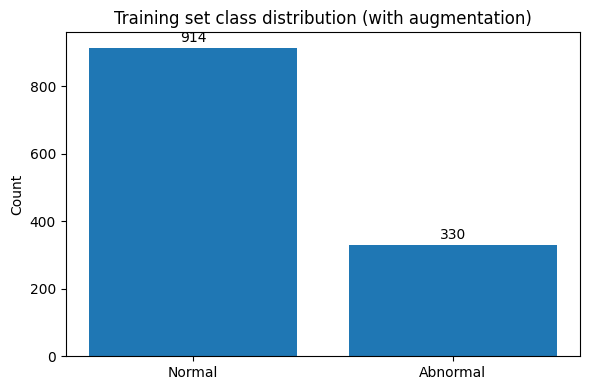

In [23]:
plt.figure(figsize=(6,4))
counts = np.bincount(y)
labels = ['Normal', 'Abnormal']
plt.bar(labels, counts)
plt.title("Training set class distribution (with augmentation)")
plt.ylabel("Count")
for i, c in enumerate(counts):
    plt.text(i, c + max(counts)*0.01, str(c), ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Preprocessing: scaler + variance thresholding**

In [8]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
# clip extreme values to reduce influence of outliers
X_scaled = np.clip(X_scaled, -10, 10)

# remove near-constant features
vt = VarianceThreshold(threshold=1e-4)
X_sel = vt.fit_transform(X_scaled)
print(f"Reduced feature dimension: {X_sel.shape[1]} (removed low-variance features)")

Reduced feature dimension: 233 (removed low-variance features)


**Define base models (safer hyperparams + early stopping for LGB/CB)**

In [24]:
base_models_cfg = {
    'LightGBM': {
        'model': lgb.LGBMClassifier,
        'params': {
            'n_estimators': 1000,
            'learning_rate': 0.05,
            'num_leaves': 24,
            'max_depth': 6,
            'min_child_samples': 20,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.2,
            'reg_lambda': 0.2,
            'random_state': RND_SEED,
            'n_jobs': -1,
            'verbose': -1,
            'class_weight': 'balanced'
        }
    },
    'CatBoost': {
        'model': CatBoostClassifier,
        'params': {
            'iterations': 1000,
            'learning_rate': 0.04,
            'depth': 6,
            'l2_leaf_reg': 5,
            'random_seed': RND_SEED,
            'verbose': 0,
            'auto_class_weights': 'Balanced'
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier,
        'params': {
            'n_estimators': 300,
            'max_depth': 14,
            'min_samples_split': 6,
            'min_samples_leaf': 2,
            'max_features': 'sqrt',
            'random_state': RND_SEED,
            'n_jobs': -1,
            'class_weight': 'balanced_subsample'
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier,
        'params': {
            'n_estimators': 300,
            'learning_rate': 0.05,
            'max_depth': 4,
            'min_samples_split': 6,
            'subsample': 0.8,
            'random_state': RND_SEED
        }
    }
}


**Stacking (OOF) training**

In [25]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RND_SEED)

oof_preds = {name: np.zeros(len(y), dtype=float) for name in base_models_cfg.keys()}
oof_meta = np.zeros((len(y), len(base_models_cfg)))
models_per_fold = {name: [] for name in base_models_cfg.keys()}
cv_scores = {name: [] for name in base_models_cfg.keys()}

print("\nPerforming Stratified K-Fold with stacking...")

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_sel, y), 1):
    print(f"\n--- Fold {fold}/{n_splits} ---")
    X_tr, X_val = X_sel[tr_idx], X_sel[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    for i, (name, cfg) in enumerate(base_models_cfg.items()):
        ModelClass = cfg['model']
        params = cfg['params'].copy()

        if name == 'LightGBM':
            # Use callbacks API for LightGBM v4.x
            m = ModelClass(**params)
            m.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                eval_metric='binary_logloss',
                callbacks=[early_stopping(50), log_evaluation(50)]
            )
        elif name == 'CatBoost':
            # CatBoost supports early_stopping_rounds in fit; keep use_best_model=True
            m = ModelClass(**params)
            # use_best_model + early_stopping_rounds for CatBoost
            m.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True, early_stopping_rounds=50, verbose=False)
        else:
            m = ModelClass(**params)
            m.fit(X_tr, y_tr)

        # store model
        models_per_fold[name].append(m)

        # get val probabilities
        try:
            val_proba = m.predict_proba(X_val)[:, 1]
        except Exception:
            # some sklearn models may not have predict_proba: fallback to decision_function
            try:
                val_proba = m.decision_function(X_val)
                val_proba = (val_proba - val_proba.min()) / (val_proba.max() - val_proba.min() + 1e-9)
            except Exception:
                val_proba = m.predict(X_val).astype(float)

        oof_preds[name][val_idx] = val_proba
        oof_meta[val_idx, i] = val_proba

        # compute F1 at 0.5 for reporting
        val_pred_bin = (val_proba >= 0.5).astype(int)
        score = f1_score(y_val, val_pred_bin)
        cv_scores[name].append(score)
        print(f"  {name}: fold F1@0.5 = {score:.4f}")


Performing Stratified K-Fold with stacking...

--- Fold 1/5 ---
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.101167
[100]	valid_0's binary_logloss: 0.0334065
[150]	valid_0's binary_logloss: 0.0171132
[200]	valid_0's binary_logloss: 0.0133838
[250]	valid_0's binary_logloss: 0.0117879
[300]	valid_0's binary_logloss: 0.011616
Early stopping, best iteration is:
[264]	valid_0's binary_logloss: 0.0116137
  LightGBM: fold F1@0.5 = 0.9924
  CatBoost: fold F1@0.5 = 0.9848
  RandomForest: fold F1@0.5 = 0.9767
  GradientBoosting: fold F1@0.5 = 0.9848

--- Fold 2/5 ---
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.133398
[100]	valid_0's binary_logloss: 0.0900228
[150]	valid_0's binary_logloss: 0.0965689
Early stopping, best iteration is:
[110]	valid_0's binary_logloss: 0.0886332
  LightGBM: fold F1@0.5 = 0.9268
  CatBoost: fold F1@0.5 = 0.9268
  RandomForest: fold F1@0.5 = 0.9268
  GradientBoosting: f

**Summary CV**

In [26]:
print("\nCROSS-VALIDATION (base models) summary:")
for name in base_models_cfg.keys():
    arr = np.array(cv_scores[name])
    print(f"  {name:20s}: {arr.mean():.4f} ± {arr.std():.4f}")


CROSS-VALIDATION (base models) summary:
  LightGBM            : 0.9649 ± 0.0252
  CatBoost            : 0.9716 ± 0.0226
  RandomForest        : 0.9589 ± 0.0171
  GradientBoosting    : 0.9623 ± 0.0167


**Meta model training on OOF predictions**

In [27]:
print("\nTraining meta-learner on OOF predictions...")
meta_clf = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=RND_SEED,
    class_weight='balanced'
)

meta_clf.fit(oof_meta, y)


Training meta-learner on OOF predictions...


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

**Threshold tuning on OOF meta predictions**

In [28]:
print("\nThreshold search on OOF meta predictions to maximize F1...")
oof_meta_pred = meta_clf.predict_proba(oof_meta)[:, 1]

best_th = 0.5
best_f1 = 0.0
for th in np.linspace(0.3, 0.7, 41):
    f = f1_score(y, (oof_meta_pred >= th).astype(int))
    if f > best_f1:
        best_f1 = f
        best_th = th

print(f"  Best OOF threshold = {best_th:.3f} with OOF F1 = {best_f1:.4f}")


Threshold search on OOF meta predictions to maximize F1...
  Best OOF threshold = 0.550 with OOF F1 = 0.9753


**Prepare test set, extract features**

In [29]:
print("PROCESSING TEST DATA")
test_files = sorted([f for f in os.listdir(TEST_PATH) if f.endswith('.wav')])
print(f"\nProcessing {len(test_files)} test samples...")

test_data = []
test_file_names = []
for file in tqdm(test_files, desc="Test"):
    fp = os.path.join(TEST_PATH, file)
    feats = load_and_extract(fp)
    if feats is not None:
        test_data.append(feats)
        test_file_names.append(file)

if len(test_data) == 0:
    raise RuntimeError("No test data loaded. Check TEST_PATH.")

X_test = np.array(test_data)
print(f"\nRaw test shape: {X_test.shape}")

# scale + variance select using previously fitted transforms
X_test_scaled = scaler.transform(X_test)
X_test_scaled = np.clip(X_test_scaled, -10, 10)
X_test_sel = vt.transform(X_test_scaled)
print(f"Test shape after preprocessing: {X_test_sel.shape}")

PROCESSING TEST DATA

Processing 156 test samples...


Test: 100%|██████████| 156/156 [02:22<00:00,  1.09it/s]


Raw test shape: (156, 233)
Test shape after preprocessing: (156, 233)


**Create base model predictions for test (average across folds)**

In [30]:
print("\nGenerating base-model predictions on test set...")
test_meta = np.zeros((len(X_test_sel), len(base_models_cfg)))

for i, (name, models_list) in enumerate(models_per_fold.items()):
    fold_preds = []
    for m in models_list:
        try:
            p = m.predict_proba(X_test_sel)[:, 1]
        except Exception:
            try:
                p_raw = m.decision_function(X_test_sel)
                p = (p_raw - p_raw.min()) / (p_raw.max() - p_raw.min() + 1e-9)
            except Exception:
                p = m.predict(X_test_sel).astype(float)
        fold_preds.append(p)
    # average across folds
    avg_p = np.mean(np.vstack(fold_preds), axis=0)
    test_meta[:, i] = avg_p
    print(f"  {name}: done")

# meta predict
meta_test_proba = meta_clf.predict_proba(test_meta)[:, 1]
final_predictions = (meta_test_proba >= best_th).astype(int)

print(f"\nFinal predictions generated")
print(f"  Normal predictions: {np.sum(final_predictions == 0)}")
print(f"  Abnormal predictions: {np.sum(final_predictions == 1)}")


Generating base-model predictions on test set...
  LightGBM: done
  CatBoost: done
  RandomForest: done
  GradientBoosting: done

Final predictions generated
  Normal predictions: 122
  Abnormal predictions: 34


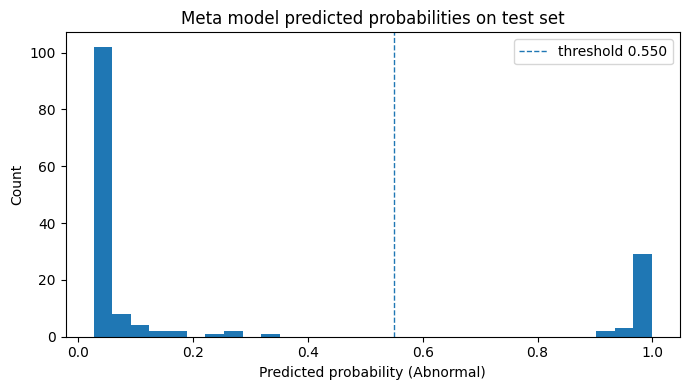

Test set counts by final prediction:
  0 -> 122
  1 -> 34


In [34]:
plt.figure(figsize=(7,4))
plt.hist(meta_test_proba, bins=30)
plt.title("Meta model predicted probabilities on test set")
plt.xlabel("Predicted probability (Abnormal)")
plt.ylabel("Count")
plt.axvline(best_th, linestyle='--', linewidth=1, label=f"threshold {best_th:.3f}")
plt.legend()
plt.tight_layout()
plt.show()

print("Test set counts by final prediction:")
unique, counts = np.unique(final_predictions, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u} -> {c}")

**Creating submission**

In [31]:
submission = pd.DataFrame({
    'file_name': test_file_names,
    'target': final_predictions
})
submission.to_csv(OUT_SUB, index=False)
print(f"\nSubmission saved to: {OUT_SUB}")
print("Preview:")
print(submission.head(10))
print("\nTarget Distribution:")
print(submission['target'].value_counts())


Submission saved to: submission_stacked.csv
Preview:
   file_name  target
0  00001.wav       0
1  00002.wav       0
2  00003.wav       0
3  00004.wav       0
4  00005.wav       0
5  00006.wav       0
6  00007.wav       0
7  00008.wav       0
8  00009.wav       0
9  00010.wav       0

Target Distribution:
target
0    122
1     34
Name: count, dtype: int64


**Evaluation Metrics**

In [32]:
oof_meta_pred_bin = (oof_meta_pred >= best_th).astype(int)

# Calculate metrics
oof_auc = roc_auc_score(y, oof_meta_pred)
oof_f1 = f1_score(y, oof_meta_pred_bin)
oof_precision = precision_score(y, oof_meta_pred_bin)
oof_recall = recall_score(y, oof_meta_pred_bin)

print(f"ROC-AUC Score     : {oof_auc:.4f}")

cm = confusion_matrix(y, oof_meta_pred_bin)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y, oof_meta_pred_bin, target_names=['Normal', 'Abnormal']))

ROC-AUC Score     : 0.9987

Confusion Matrix:
[[912   2]
 [ 14 316]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       914
    Abnormal       0.99      0.96      0.98       330

    accuracy                           0.99      1244
   macro avg       0.99      0.98      0.98      1244
weighted avg       0.99      0.99      0.99      1244



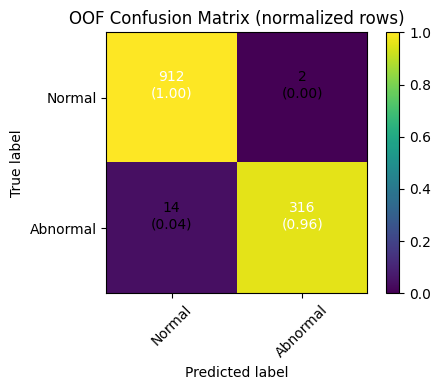

In [33]:
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

plt.figure(figsize=(5,4))
plt.imshow(cm_norm, interpolation='nearest', vmin=0, vmax=1)
plt.title("OOF Confusion Matrix (normalized rows)")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Normal','Abnormal'], rotation=45)
plt.yticks(tick_marks, ['Normal','Abnormal'])
thresh = cm_norm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i,j]:d}\n({cm_norm[i,j]:.2f})",
                 horizontalalignment="center",
                 color="white" if cm_norm[i,j] > thresh else "black")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()